In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,precision_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\Project-Injury-Dataset.csv")
df

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
0,basketball,1,Sabrina Glenn,24,195,108,Center,ACL Tear,Severe,Physiotherapy,7,0,2017-12-19 00:00:00,0.862860,78.327638,77.705191,37.926663,56.578469,64.259747
1,basketball,2,Brenda Weber,32,183,87,Forward,Ankle Sprain,Mild,Physiotherapy,8,1,2017-08-10 00:00:00,0.806708,32.751850,83.215950,98.938884,71.320646,45.484661
2,basketball,3,Tamara Guzman,28,208,109,Center,Knee Injury,Moderate,Flexibility Exercises,3,0,2018-11-21 00:00:00,0.709122,85.958728,71.694712,88.722866,48.764455,99.136761
3,basketball,4,Meredith Russell,25,196,70,Forward,Shoulder Dislocation,Moderate,Strength Training,11,1,2017-07-18 00:00:00,0.966364,73.953027,63.010333,38.726388,73.690424,96.084154
4,basketball,5,Bruce Jones,24,178,80,Guard,Shoulder Dislocation,Moderate,Balance Training,3,0,2015-03-05 00:00:00,0.933032,35.723132,58.828864,94.458932,58.658816,32.759877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,Gym,1080,Chris Elliott,25,191,91,Center,Rotator Cuff Injury,Moderate,Physiotherapy,7,1,2013-12-29 00:00:00,0.745913,61.423338,69.822917,58.739437,62.926583,68.880680
9596,Gym,7980,Kevin Baker,32,198,51,Batsman,Elbow Pain,Mild,Physiotherapy,5,0,2020-06-02,0.873331,81.576909,91.082987,52.653274,67.128295,74.181400
9597,Gym,1116,Nicole Nguyen,25,190,92,Forward,Tendonitis,Severe,Balance Training,6,1,2020-03-19 00:00:00,0.742516,62.339017,67.609491,61.131492,63.132485,67.130565
9598,Gym,6094,Linda Humphrey,38,168,83,Doubles,Elbow Pain,Severe,Flexibility Exercises,5,0,2015-04-04,0.957539,38.154820,54.802039,61.843169,69.406282,74.953008


In [ ]:
df.head()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
0,basketball,1,Sabrina Glenn,24,195,108,Center,ACL Tear,Severe,Physiotherapy,7,0,2017-12-19 00:00:00,0.862860,78.327638,77.705191,37.926663,56.578469,64.259747
1,basketball,2,Brenda Weber,32,183,87,Forward,Ankle Sprain,Mild,Physiotherapy,8,1,2017-08-10 00:00:00,0.806708,32.751850,83.215950,98.938884,71.320646,45.484661
2,basketball,3,Tamara Guzman,28,208,109,Center,Knee Injury,Moderate,Flexibility Exercises,3,0,2018-11-21 00:00:00,0.709122,85.958728,71.694712,88.722866,48.764455,99.136761
3,basketball,4,Meredith Russell,25,196,70,Forward,Shoulder Dislocation,Moderate,Strength Training,11,1,2017-07-18 00:00:00,0.966364,73.953027,63.010333,38.726388,73.690424,96.084154
4,basketball,5,Bruce Jones,24,178,80,Guard,Shoulder Dislocation,Moderate,Balance Training,3,0,2015-03-05 00:00:00,0.933032,35.723132,58.828864,94.458932,58.658816,32.759877


In [ ]:
df.tail()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
9595,Gym,1080,Chris Elliott,25,191,91,Center,Rotator Cuff Injury,Moderate,Physiotherapy,7,1,2013-12-29 00:00:00,0.745913,61.423338,69.822917,58.739437,62.926583,68.880680
9596,Gym,7980,Kevin Baker,32,198,51,Batsman,Elbow Pain,Mild,Physiotherapy,5,0,2020-06-02,0.873331,81.576909,91.082987,52.653274,67.128295,74.181400
9597,Gym,1116,Nicole Nguyen,25,190,92,Forward,Tendonitis,Severe,Balance Training,6,1,2020-03-19 00:00:00,0.742516,62.339017,67.609491,61.131492,63.132485,67.130565
9598,Gym,6094,Linda Humphrey,38,168,83,Doubles,Elbow Pain,Severe,Flexibility Exercises,5,0,2015-04-04,0.957539,38.154820,54.802039,61.843169,69.406282,74.953008
9599,Gym,6833,Tina Wallace,21,172,72,Bowler,Tendonitis,Moderate,Physiotherapy,9,0,2017-04-12,0.825992,71.155416,82.309194,79.322377,57.861403,93.898373


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Sport                            9600 non-null   object 
 1   Player_ID                        9600 non-null   int64  
 2   PLAYER_NAME                      9600 non-null   object 
 3   Age                              9600 non-null   int64  
 4   Height_cm                        9600 non-null   int64  
 5   Weight_kg                        9600 non-null   int64  
 6   Position / Exercise_Type         9600 non-null   object 
 7   Injury_Type                      9600 non-null   object 
 8   Injury_Severity                  9600 non-null   object 
 9   Rehabilitation_Program           9600 non-null   object 
 10  Rehabilitation_Time_weeks        9600 non-null   int64  
 11  Injury_Recurrence                9600 non-null   int64  
 12  Date_of_Injury      

In [ ]:
df.describe()

,Player_ID,Age,Height_cm,Weight_kg,Rehabilitation_Time_weeks,Injury_Recurrence,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
count,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000
mean,3994.420729,27.465521,181.280625,83.183021,7.118750,0.485729,0.768938,57.580790,61.435204,63.076183,34.106983,183.308146
std,2314.652256,3.713999,9.312171,11.927829,1.807793,0.499822,0.079867,10.161453,15.354834,11.242822,28.901452,118.484784
min,1.000000,18.000000,152.000000,50.000000,1.000000,0.000000,0.500507,20.030000,10.120000,21.680000,3.020000,30.009563
25%,1979.000000,25.000000,172.000000,73.000000,6.000000,0.000000,0.742877,53.418826,46.521222,60.019243,5.827500,67.350066
50%,3997.500000,27.000000,184.000000,88.000000,7.000000,0.000000,0.782565,56.313933,62.839625,62.524435,40.063890,99.345626
75%,5999.250000,29.000000,189.000000,91.000000,8.000000,1.000000,0.799285,61.117161,68.868281,65.109942,63.825224,301.409019
max,8000.000000,39.000000,209.000000,119.000000,15.000000,1.000000,1.000000,99.297216,99.964742,99.980831,98.908153,399.500000


In [ ]:
df.size

182400

In [ ]:
df.shape

(9600, 19)

In [ ]:
df.dtypes

Sport                               object
Player_ID                            int64
PLAYER_NAME                         object
Age                                  int64
Height_cm                            int64
Weight_kg                            int64
Position / Exercise_Type            object
Injury_Type                         object
Injury_Severity                     object
Rehabilitation_Program              object
Rehabilitation_Time_weeks            int64
Injury_Recurrence                    int64
Date_of_Injury                      object
Rehabilitation_Efficiency_Score    float64
Knee_Angle_deg                     float64
Jump_Height_cm                     float64
Ankle_Flexion_deg                  float64
Speed_m_s                          float64
Reaction_Time_ms                   float64
dtype: object

In [ ]:
df.nunique()

Sport                                 6
Player_ID                          8000
PLAYER_NAME                        7828
Age                                  22
Height_cm                            56
Weight_kg                            69
Position / Exercise_Type             12
Injury_Type                          17
Injury_Severity                       3
Rehabilitation_Program                4
Rehabilitation_Time_weeks            15
Injury_Recurrence                     2
Date_of_Injury                     4735
Rehabilitation_Efficiency_Score    7841
Knee_Angle_deg                     7997
Jump_Height_cm                     7998
Ankle_Flexion_deg                  7999
Speed_m_s                          7978
Reaction_Time_ms                   7998
dtype: int64

In [ ]:
df.columns

Index(['Sport', 'Player_ID', 'PLAYER_NAME', 'Age', 'Height_cm', 'Weight_kg',
       'Position / Exercise_Type', 'Injury_Type', 'Injury_Severity',
       'Rehabilitation_Program', 'Rehabilitation_Time_weeks',
       'Injury_Recurrence', 'Date_of_Injury',
       'Rehabilitation_Efficiency_Score', 'Knee_Angle_deg', 'Jump_Height_cm',
       'Ankle_Flexion_deg', 'Speed_m_s', 'Reaction_Time_ms'],
      dtype='object')

In [ ]:
df.isnull().sum()

Sport                              0
Player_ID                          0
PLAYER_NAME                        0
Age                                0
Height_cm                          0
Weight_kg                          0
Position / Exercise_Type           0
Injury_Type                        0
Injury_Severity                    0
Rehabilitation_Program             0
Rehabilitation_Time_weeks          0
Injury_Recurrence                  0
Date_of_Injury                     0
Rehabilitation_Efficiency_Score    0
Knee_Angle_deg                     0
Jump_Height_cm                     0
Ankle_Flexion_deg                  0
Speed_m_s                          0
Reaction_Time_ms                   0
dtype: int64

In [ ]:
df.corr(numeric_only=True)

,Player_ID,Age,Height_cm,Weight_kg,Rehabilitation_Time_weeks,Injury_Recurrence,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
Player_ID,1.000000,0.247799,-0.514093,-0.487472,0.026152,0.003834,0.001056,-0.031245,-0.001075,0.130997,-0.060333,0.000892
Age,0.247799,1.000000,-0.094568,-0.064284,0.046041,0.004000,0.032273,-0.083768,0.009756,0.047127,-0.206124,0.191415
Height_cm,-0.514093,-0.094568,1.000000,0.474450,-0.156391,-0.013599,-0.105457,0.120198,0.424682,-0.069676,0.380608,-0.353488
Weight_kg,-0.487472,-0.064284,0.474450,1.000000,-0.112133,-0.009531,-0.022563,0.044361,0.305206,-0.065424,0.214069,-0.189209
Rehabilitation_Time_weeks,0.026152,0.046041,-0.156391,-0.112133,1.000000,0.001184,0.090631,-0.071054,-0.271499,0.005019,-0.351816,0.350918
Injury_Recurrence,0.003834,0.004000,-0.013599,-0.009531,0.001184,1.000000,0.013844,0.013308,-0.007523,-0.012775,-0.005592,0.004736
Rehabilitation_Efficiency_Score,0.001056,0.032273,-0.105457,-0.022563,0.090631,0.013844,1.000000,-0.052345,-0.203306,0.018537,-0.287104,0.286842
Knee_Angle_deg,-0.031245,-0.083768,0.120198,0.044361,-0.071054,0.013308,-0.052345,1.000000,0.194672,-0.004860,0.272062,-0.284325
Jump_Height_cm,-0.001075,0.009756,0.424682,0.305206,-0.271499,-0.007523,-0.203306,0.194672,1.000000,0.001821,0.655613,-0.674960
Ankle_Flexion_deg,0.130997,0.047127,-0.069676,-0.065424,0.005019,-0.012775,0.018537,-0.004860,0.001821,1.000000,-0.021527,0.027470


In [ ]:
# dist plot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19936\2174373618.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[ 'Speed_m_s'],color='g')


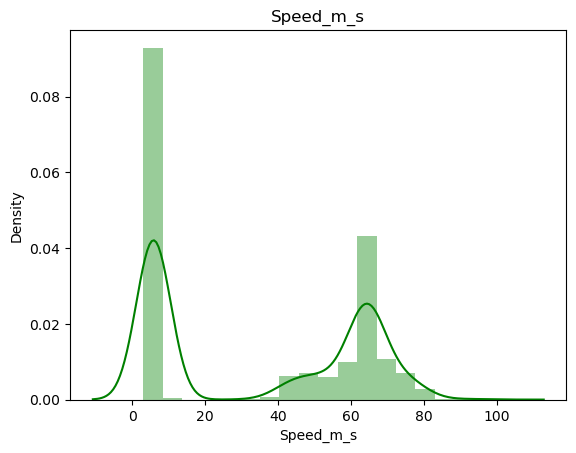

In [ ]:
sns.distplot(df[ 'Speed_m_s'],color='g')
plt.title( 'Speed_m_s')
plt.show()

In [ ]:
# pie chart

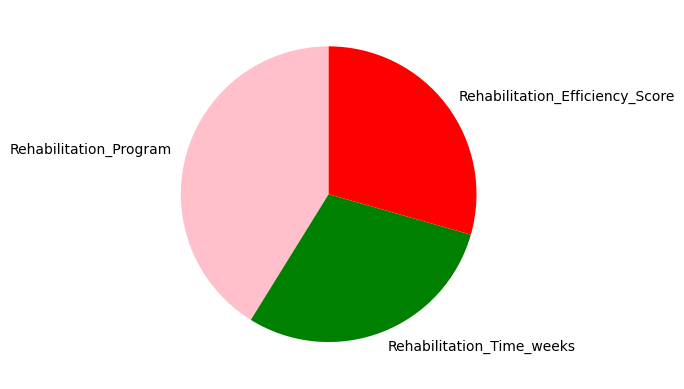

In [ ]:
y=np.array([35,25,25])
mylabels=['Rehabilitation_Program', 'Rehabilitation_Time_weeks', 'Rehabilitation_Efficiency_Score']
mycolors=["pink","green","r"]
plt.pie(y,labels=mylabels,colors=mycolors,startangle=90)
plt.show()

In [ ]:
# count plot

<Axes: xlabel='Position / Exercise_Type', ylabel='count'>

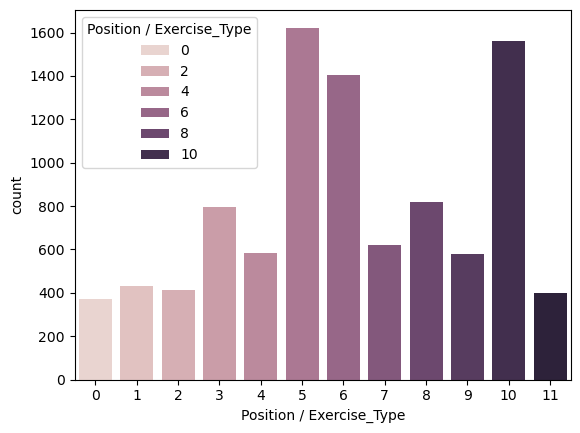

In [ ]:
sns.countplot(x= 'Position / Exercise_Type',hue= 'Position / Exercise_Type',data=df)

In [ ]:
# bar plot

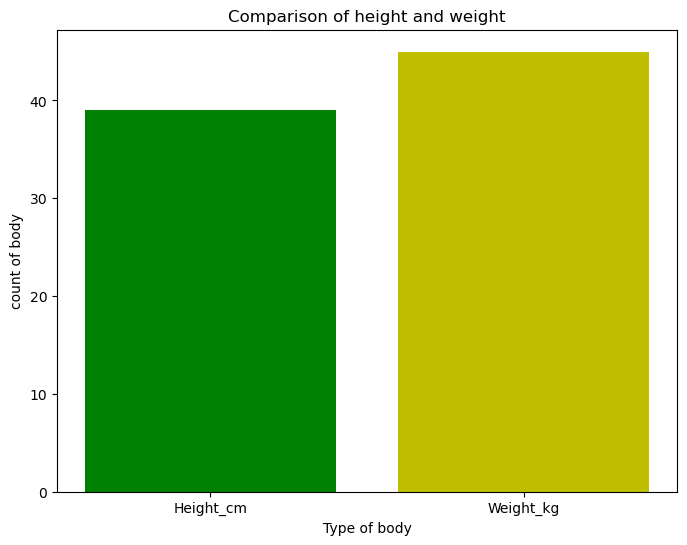

In [ ]:
# Data for height and weight
body_types = [  'Height_cm', 'Weight_kg' ]
body_counts = [39, 45]
# Create bar plot
plt.figure(figsize=(8, 6))
plt.bar(body_types, body_counts, color=['g', 'y'])
plt.xlabel('Type of body')
plt.ylabel('count of body')
plt.title('Comparison of height and weight')
plt.show()

In [ ]:
# heat map

In [ ]:
df1=df.corr(numeric_only=True)
df1

,Player_ID,Age,Height_cm,Weight_kg,Rehabilitation_Time_weeks,Injury_Recurrence,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
Player_ID,1.000000,0.247799,-0.514093,-0.487472,0.026152,0.003834,0.001056,-0.031245,-0.001075,0.130997,-0.060333,0.000892
Age,0.247799,1.000000,-0.094568,-0.064284,0.046041,0.004000,0.032273,-0.083768,0.009756,0.047127,-0.206124,0.191415
Height_cm,-0.514093,-0.094568,1.000000,0.474450,-0.156391,-0.013599,-0.105457,0.120198,0.424682,-0.069676,0.380608,-0.353488
Weight_kg,-0.487472,-0.064284,0.474450,1.000000,-0.112133,-0.009531,-0.022563,0.044361,0.305206,-0.065424,0.214069,-0.189209
Rehabilitation_Time_weeks,0.026152,0.046041,-0.156391,-0.112133,1.000000,0.001184,0.090631,-0.071054,-0.271499,0.005019,-0.351816,0.350918
Injury_Recurrence,0.003834,0.004000,-0.013599,-0.009531,0.001184,1.000000,0.013844,0.013308,-0.007523,-0.012775,-0.005592,0.004736
Rehabilitation_Efficiency_Score,0.001056,0.032273,-0.105457,-0.022563,0.090631,0.013844,1.000000,-0.052345,-0.203306,0.018537,-0.287104,0.286842
Knee_Angle_deg,-0.031245,-0.083768,0.120198,0.044361,-0.071054,0.013308,-0.052345,1.000000,0.194672,-0.004860,0.272062,-0.284325
Jump_Height_cm,-0.001075,0.009756,0.424682,0.305206,-0.271499,-0.007523,-0.203306,0.194672,1.000000,0.001821,0.655613,-0.674960
Ankle_Flexion_deg,0.130997,0.047127,-0.069676,-0.065424,0.005019,-0.012775,0.018537,-0.004860,0.001821,1.000000,-0.021527,0.027470


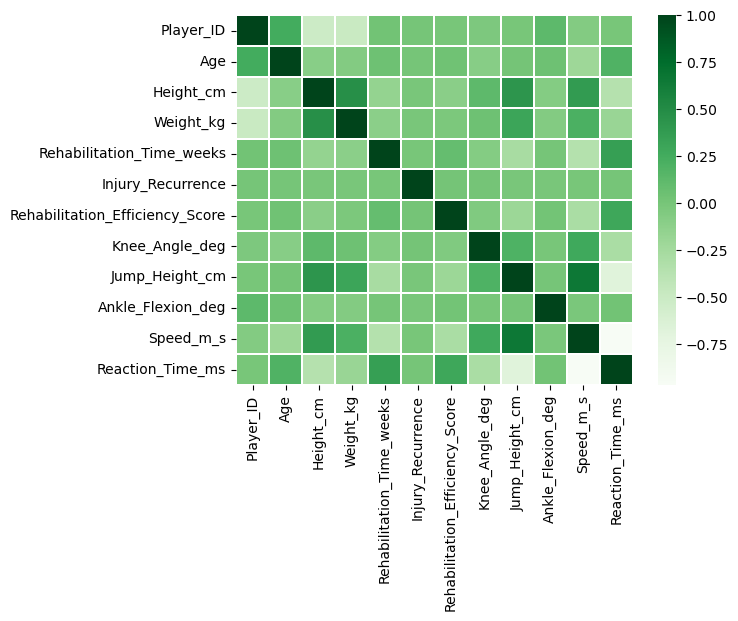

In [ ]:
sns.heatmap(df.corr(numeric_only=True),linewidth='.1',cmap='Greens')
plt.show()

In [ ]:
# label encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x=['Sport', 'PLAYER_NAME', 'Position / Exercise_Type','Injury_Type','Injury_Severity','Rehabilitation_Program','Date_of_Injury']
for i in x:
   df[i]=le.fit_transform(df[i])
df.head()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Injury_Recurrence,Date_of_Injury,Rehabilitation_Efficiency_Score,Knee_Angle_deg,Jump_Height_cm,Ankle_Flexion_deg,Speed_m_s,Reaction_Time_ms
0,3,1,6481,24,195,108,3,0,2,2,7,0,1815,0.862860,78.327638,77.705191,37.926663,56.578469,64.259747
1,3,2,915,32,183,87,6,1,0,2,8,1,1616,0.806708,32.751850,83.215950,98.938884,71.320646,45.484661
2,3,3,7142,28,208,109,3,8,1,1,3,0,2329,0.709122,85.958728,71.694712,88.722866,48.764455,99.136761
3,3,4,5231,25,196,70,6,12,1,3,11,1,1583,0.966364,73.953027,63.010333,38.726388,73.690424,96.084154
4,3,5,1055,24,178,80,8,12,1,0,3,0,307,0.933032,35.723132,58.828864,94.458932,58.658816,32.759877


In [ ]:
x = df.drop('Injury_Recurrence',axis=1)
y = df['Injury_Recurrence']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled=minmax.fit_transform(x)
x_scaled

array([[6.00000000e-01, 0.00000000e+00, 8.28031174e-01, ...,
        2.07490303e-01, 5.58551469e-01, 9.26957258e-02],
       [6.00000000e-01, 1.25015627e-04, 1.16903028e-01, ...,
        9.86693023e-01, 7.12294940e-01, 4.18822685e-02],
       [6.00000000e-01, 2.50031254e-04, 9.12482433e-01, ...,
        8.56221639e-01, 4.77060550e-01, 1.87087920e-01],
       ...,
       [4.00000000e-01, 1.39392424e-01, 7.44602019e-01, ...,
        5.03845127e-01, 6.26902105e-01, 1.00465394e-01],
       [4.00000000e-01, 7.61720215e-01, 5.92180912e-01, ...,
        5.12934130e-01, 6.92330384e-01, 1.21636288e-01],
       [4.00000000e-01, 8.54106763e-01, 9.45956305e-01, ...,
        7.36165578e-01, 5.71930961e-01, 1.72910590e-01]])

In [ ]:
x = pd.DataFrame(x_scaled,columns=['Sport', 'Player_ID', 'PLAYER_NAME', 'Age', 'Height_cm', 'Weight_kg',
       'Position / Exercise_Type', 'Injury_Type', 'Injury_Severity', 'Rehabilitation_Program',
       'Rehabilitation_Time_weeks', 'Date_of_Injury',
       'Rehabilitation_Efficiency_Score', 'knee_angle_deg', 'jump_height_cm',
       'ankle_flexion_deg', 'speed_m_s', 'reaction_time_ms'])

In [ ]:
x

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Date_of_Injury,Rehabilitation_Efficiency_Score,knee_angle_deg,jump_height_cm,ankle_flexion_deg,speed_m_s,reaction_time_ms
0,0.6,0.000000,0.828031,0.285714,0.754386,0.840580,0.272727,0.0000,1.0,0.666667,0.428571,0.383397,0.725441,0.735457,0.752244,0.207490,0.558551,0.092696
1,0.6,0.000125,0.116903,0.666667,0.543860,0.536232,0.545455,0.0625,0.0,0.666667,0.500000,0.341360,0.613023,0.160493,0.813581,0.986693,0.712295,0.041882
2,0.6,0.000250,0.912482,0.476190,0.982456,0.855072,0.272727,0.5000,0.5,0.333333,0.142857,0.491973,0.417652,0.831728,0.685346,0.856222,0.477061,0.187088
3,0.6,0.000375,0.668328,0.333333,0.771930,0.289855,0.545455,0.7500,0.5,1.000000,0.714286,0.334390,0.932660,0.680269,0.588686,0.217704,0.737009,0.178826
4,0.6,0.000500,0.134790,0.285714,0.456140,0.434783,0.727273,0.7500,0.5,0.000000,0.142857,0.064850,0.865928,0.197978,0.542145,0.929478,0.580247,0.007444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,0.4,0.134892,0.169414,0.333333,0.684211,0.594203,0.272727,0.6875,0.5,0.666667,0.428571,0.003380,0.491311,0.522200,0.664512,0.473296,0.624755,0.105202
9596,0.4,0.997500,0.544909,0.666667,0.807018,0.014493,0.090909,0.2500,0.0,0.666667,0.285714,0.677651,0.746405,0.776448,0.901143,0.395568,0.668574,0.119548
9597,0.4,0.139392,0.744602,0.333333,0.666667,0.608696,0.545455,0.9375,1.0,0.000000,0.357143,0.646810,0.484509,0.533752,0.639876,0.503845,0.626902,0.100465
9598,0.4,0.761720,0.592181,0.952381,0.280702,0.478261,0.454545,0.2500,1.0,0.333333,0.285714,0.074567,0.914992,0.228655,0.497325,0.512934,0.692330,0.121636


In [ ]:
x.describe()

,Sport,Player_ID,PLAYER_NAME,Age,Height_cm,Weight_kg,Position / Exercise_Type,Injury_Type,Injury_Severity,Rehabilitation_Program,Rehabilitation_Time_weeks,Date_of_Injury,Rehabilitation_Efficiency_Score,knee_angle_deg,jump_height_cm,ankle_flexion_deg,speed_m_s,reaction_time_ms
count,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000
mean,0.587500,0.499240,0.500032,0.450739,0.513695,0.480913,0.555123,0.395879,0.505313,0.505556,0.437054,0.597959,0.537408,0.473724,0.571154,0.528681,0.324200,0.414892
std,0.319929,0.289368,0.288626,0.176857,0.163371,0.172867,0.271679,0.319955,0.406893,0.371318,0.129128,0.286865,0.159895,0.128192,0.170904,0.143585,0.301408,0.320671
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,0.247281,0.249106,0.333333,0.350877,0.333333,0.363636,0.062500,0.000000,0.333333,0.357143,0.364544,0.485233,0.421219,0.405157,0.489640,0.029279,0.101059
50%,0.600000,0.499625,0.501469,0.428571,0.561404,0.550725,0.545455,0.375000,0.500000,0.666667,0.428571,0.686946,0.564689,0.457742,0.586786,0.521635,0.386324,0.187653
75%,0.800000,0.749875,0.747956,0.523810,0.649123,0.594203,0.818182,0.625000,1.000000,1.000000,0.500000,0.830587,0.598162,0.518337,0.653887,0.554655,0.634127,0.734524
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
# random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf= RandomForestClassifier(random_state=42)
rf_model=rf_clf.fit(xtrain,ytrain)
# model creation
y_pred_rf=rf_model.predict(xtest)
# y predictions

In [ ]:
# model validation checking
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,classification_report

In [ ]:
rf_score=accuracy_score(ytest,y_pred_rf)
rf_score

0.6554166666666666

In [ ]:
# decision tree classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf= DecisionTreeClassifier(random_state=42)

dt_model=dt_clf.fit(xtrain,ytrain)
# model creation
y_pred_dt=dt_model.predict(xtest)
# y predictions

In [ ]:
dt_score=accuracy_score(ytest,y_pred_dt)
dt_score

0.6416666666666667

In [ ]:
# naive bayes classifier

In [ ]:
# gaussian nb

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb_clf = GaussianNB()
gnb_model=gnb_clf.fit(xtrain,ytrain)
# model creation
y_pred_gnb=gnb_model.predict(xtest)

In [ ]:
gnb_score=accuracy_score(ytest,y_pred_gnb)
gnb_score

0.4979166666666667

In [ ]:
# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()
lr_model=lr_clf.fit(xtrain,ytrain)
# model creation
y_pred_lr=lr_model.predict(xtest)

In [ ]:
lr_score=accuracy_score(ytest,y_pred_lr)
lr_score

0.515

In [ ]:
# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf= GradientBoostingClassifier()
gb_model=gb_clf.fit(xtrain,ytrain)
y_pred_gb=gb_model.predict(xtest)

In [ ]:
gb_score=accuracy_score(ytest,y_pred_gb)
gb_score

0.5595833333333333

In [ ]:
print(rf_score, dt_score, gnb_score, lr_score, gb_score)

0.6554166666666666 0.6416666666666667 0.4979166666666667 0.515 0.5595833333333333


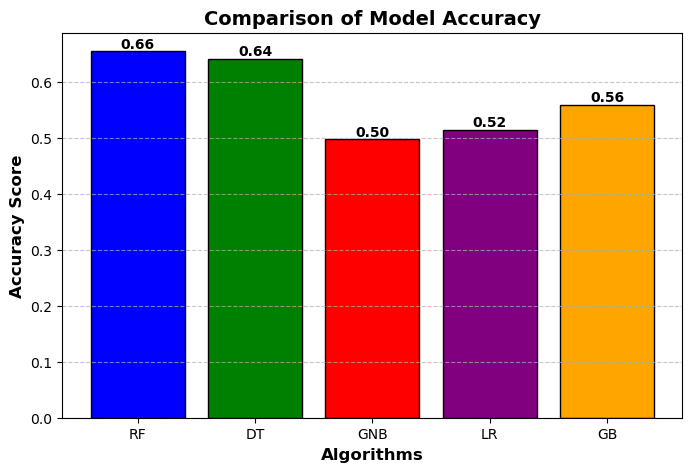

In [ ]:
import matplotlib.pyplot as plt

# Define algorithms and their corresponding scores
algorithms = ["RF", "DT", "GNB", "LR", "GB"]
scores = [rf_score, dt_score, gnb_score, lr_score, gb_score]

# Set up the figure and axis
plt.figure(figsize=(8, 5))
bars = plt.bar(algorithms, scores, color=['blue', 'green', 'red', 'purple', 'orange'], edgecolor='black')

# Add title and labels
plt.xlabel("Algorithms", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12, fontweight='bold')
plt.title("Comparison of Model Accuracy", fontsize=14, fontweight='bold')

# Display accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [ ]:
import pickle

# Assuming 'rf_model' is your trained Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Random Forest Model saved successfully!")


Random Forest Model saved successfully!


In [ ]:
with open("random_forest_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Random Forest Model loaded successfully!")


Random Forest Model loaded successfully!


In [ ]:
# Pose Estimation for Performance Analysis

In [ ]:
# pip install opencv-python mediapipe
# (MediaPipe to analyze a player's posture)

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()
mp_drawing = mp.solutions.drawing_utils

# Open video
cap = cv2.VideoCapture(r"C:\Users\Lenovo\OneDrive\Desktop\SportsVideos\gym-2.mp4")

# Initialize injury risk accumulator
total_severity = 0  # Accumulated severity score
frame_count = 0  # To count frames for smoother risk calculation
smoothing_factor = 0.1  # A smoothing factor to reduce abrupt changes in risk

# Pause flag
is_paused = False

# Function to detect incorrect posture and give feedback
def detect_incorrect_posture(results, sport_type='gym'):
    feedback = []
    severity = 0  # Severity of posture issues, dynamically calculated
    
    if results.pose_landmarks:
        left_shoulder = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_SHOULDER]
        right_shoulder = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_SHOULDER]
        shoulder_distance = np.abs(left_shoulder.x - right_shoulder.x)

        if sport_type == 'general':
            if shoulder_distance < 0.15:
                feedback.append("Warning: Your shoulders are too close! Maintain a proper stance.")
                severity += 20

        head = results.pose_landmarks.landmark[mp_pose.PoseLandmark.NOSE]
        neck = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_SHOULDER]
        if np.abs(head.y - neck.y) > 0.1:
            feedback.append("Posture Warning: Keep your head aligned with your neck.")
            severity += 25

        if sport_type == 'football':
            left_knee = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_KNEE]
            right_knee = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_KNEE]
            knee_bend = np.abs(left_knee.y - right_knee.y)
            if knee_bend > 0.2:
                feedback.append("Knees should be more aligned. Adjust your posture.")
                severity += 30

        if sport_type == 'tennis':
            left_elbow = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_ELBOW]
            right_elbow = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_ELBOW]
            if np.abs(left_elbow.x - right_elbow.x) > 0.2:
                feedback.append("Ensure proper arm positioning for better control.")
                severity += 15

        if sport_type == 'basketball':
            left_knee = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_KNEE]
            right_knee = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_KNEE]
            knee_bend = np.abs(left_knee.y - right_knee.y)
            if knee_bend < 0.1:
                feedback.append("Bend your knees more for a strong stance and better balance.")
                severity += 20

        if sport_type == 'badminton':
            left_wrist = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_WRIST]
            right_wrist = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_WRIST]
            if np.abs(left_wrist.y - right_wrist.y) > 0.15:
                feedback.append("Keep your wrists aligned for accurate shots.")
                severity += 15

        if sport_type == 'cricket':
            left_hip = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_HIP]
            right_hip = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_HIP]
            if np.abs(left_hip.y - right_hip.y) > 0.2:
                feedback.append("Maintain a balanced hip position for stability.")
                severity += 25

        if sport_type == 'gym':
            left_knee = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_KNEE]
            right_knee = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_KNEE]
            left_hip = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_HIP]
            right_hip = results.pose_landmarks.landmark[mp_pose.PoseLandmark.RIGHT_HIP]

            knee_hip_alignment = np.abs(left_knee.y - left_hip.y) < 0.2 and np.abs(right_knee.y - right_hip.y) < 0.2
            if not knee_hip_alignment:
                feedback.append("Knees should align with your hips and feet for a proper squat.")
                severity += 30

            torso = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_SHOULDER]
            lower_back = results.pose_landmarks.landmark[mp_pose.PoseLandmark.LEFT_HIP]
            back_alignment = np.abs(torso.y - lower_back.y) < 0.3
            if not back_alignment:
                feedback.append("Keep your back straight and avoid leaning too much forward.")
                severity += 35

    if not feedback:
        feedback.append("Posture is good!")
    
    return feedback, severity

# Function to calculate and return injury risk percentage based on accumulated severity
def calculate_injury_risk(severity):
    max_severity = 100  # Maximum severity level for injury risk calculation
    injury_risk = min(severity, max_severity)  # Ensure the injury risk doesn't exceed 100%
    return injury_risk

# Process video frame by frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(rgb_frame)
    
    # Get posture feedback for this frame and calculate severity
    feedback, frame_severity = detect_incorrect_posture(results, sport_type='gym')
    
    # Accumulate severity with a smoothing factor
    total_severity = total_severity * (1 - smoothing_factor) + frame_severity * smoothing_factor
    
    # Calculate injury risk for this frame, considering accumulated severity
    injury_risk = calculate_injury_risk(total_severity)

    # Draw pose landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

    # Show feedback and injury risk on the frame
    feedback_text = '\n'.join(feedback)  # Display all feedback messages
    cv2.putText(frame, feedback_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.putText(frame, f"Injury Risk: {injury_risk:.2f}%", (10, 400), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    # Display the resulting frame
    cv2.imshow("Pose Estimation", frame)
    
    # Wait for keypress (Pause on spacebar)
    key = cv2.waitKey(10) & 0xFF
    if key == ord('q'):  # Quit the program
        break
    elif key == 32:  # Spacebar to pause/unpause
        is_paused = not is_paused
        while is_paused:
            cv2.putText(frame, "Paused. Press SPACE to resume.", (10, 450), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
            cv2.imshow("Pose Estimation", frame)
            key = cv2.waitKey(10) & 0xFF
            if key == 32:  # Spacebar to resume
                is_paused = False

cap.release()
cv2.destroyAllWindows()
